In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to  : {SEED}')

TensorFlow version : 2.20.0
Random seed set to  : 42


In [3]:
RESULTS_DIR = '/content/drive/MyDrive/ME13/results/'
MODEL_DIR   = '/content/drive/MyDrive/ME13/model/'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)
print('Results will be saved to:', RESULTS_DIR)
print('Models  will be saved to:', MODEL_DIR)

Results will be saved to: /content/drive/MyDrive/ME13/results/
Models  will be saved to: /content/drive/MyDrive/ME13/model/


In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('No GPU found — training will run on CPU.')

GPUs available: 1
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
import kagglehub

# Dataset: abdallahalidev/plantvillage-dataset
# Structure:
#   color/      Potato___Early_blight/
#               Potato___Late_blight/
#               Potato___healthy/
#               ... (38 total classes)
#   grayscale/  (same structure)
#   segmented/  (same structure)
#
# We use color/ only, and only Early_blight and Late_blight.
# No pre-made splits — we build 70/15/15 at runtime.
path = kagglehub.dataset_download('abdallahalidev/plantvillage-dataset')
print('Path to dataset files:', path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [6]:
# Walk top levels to confirm structure
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth <= 2:
        n_files = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        label   = f'  ({n_files} images)' if n_files else ''
        name    = Path(root).name
        if 'potato' in name.lower() or depth <= 1:
            print('  ' * depth + name + label)
    if depth >= 2:
        dirs[:] = []

plantvillage-dataset
  plantvillage dataset


In [7]:
# Locate Early_blight and Late_blight under color/ only.
# Uses substring matching on lowercased folder name.
# Skips grayscale/ and segmented/ by requiring parent == 'color'.

found = {}
for dirpath, dirnames, filenames in os.walk(path):
    base   = Path(dirpath).name.lower()
    parent = Path(dirpath).parent.name.lower()
    n_imgs = len([f for f in filenames if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    if parent != 'color' or n_imgs == 0:
        continue

    if 'potato' in base and 'early' in base:
        found['Early_Blight'] = Path(dirpath)
    elif 'potato' in base and 'late' in base:
        found['Late_Blight'] = Path(dirpath)

early_dir = found.get('Early_Blight')
late_dir  = found.get('Late_Blight')

print('Early Blight dir:', early_dir)
print('Late Blight  dir:', late_dir)

assert early_dir is not None, f'Could not find Potato Early Blight under color/ in {path}'
assert late_dir  is not None, f'Could not find Potato Late Blight under color/ in {path}'

Early Blight dir: /kaggle/input/plantvillage-dataset/plantvillage dataset/color/Potato___Early_blight
Late Blight  dir: /kaggle/input/plantvillage-dataset/plantvillage dataset/color/Potato___Late_blight


In [8]:
def count_images(d):
    if d is None or not Path(d).exists():
        return 0
    exts = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    return sum(len(list(Path(d).rglob(e))) for e in exts)

n_early = count_images(early_dir)
n_late  = count_images(late_dir)
print(f'Early Blight images: {n_early}')
print(f'Late Blight  images: {n_late}')
print(f'Total              : {n_early + n_late}')

Early Blight images: 1000
Late Blight  images: 1000
Total              : 2000


In [9]:
# Build train / val / test split — 70% train | 15% val | 15% test (per class)

SPLIT_ROOT  = '/content/potato_split'
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

CLASS_MAP = {
    'Early_Blight': early_dir,
    'Late_Blight':  late_dir,
}

def build_split_dirs(split_root, class_map, train_ratio, val_ratio, seed=42):
    """Copy images from raw class folders into train/val/test directory tree."""
    rng  = random.Random(seed)
    exts = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

    for split in ('train', 'val', 'test'):
        for cls in class_map:
            os.makedirs(os.path.join(split_root, split, cls), exist_ok=True)

    for cls, src_dir in class_map.items():
        all_imgs = [
            p for p in Path(src_dir).iterdir()
            if p.is_file() and p.suffix in exts
        ]
        rng.shuffle(all_imgs)

        n       = len(all_imgs)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        splits = {
            'train': all_imgs[:n_train],
            'val':   all_imgs[n_train : n_train + n_val],
            'test':  all_imgs[n_train + n_val :],
        }

        for split_name, imgs in splits.items():
            dst = os.path.join(split_root, split_name, cls)
            for img in imgs:
                shutil.copy2(img, os.path.join(dst, img.name))
            print(f'  {split_name:>5} / {cls:<14}: {len(imgs)} images')

if not Path(SPLIT_ROOT).exists():
    print('Building train / val / test split...')
    build_split_dirs(SPLIT_ROOT, CLASS_MAP, TRAIN_RATIO, VAL_RATIO, seed=SEED)
    print('Done.')
else:
    print('Split already exists at', SPLIT_ROOT)

Building train / val / test split...
  train / Early_Blight  : 700 images
    val / Early_Blight  : 150 images
   test / Early_Blight  : 150 images
  train / Late_Blight   : 700 images
    val / Late_Blight   : 150 images
   test / Late_Blight   : 150 images
Done.


In [10]:
for split in ('train', 'val', 'test'):
    split_path = Path(SPLIT_ROOT) / split
    total = count_images(split_path)
    print(f'{split:>5} : {total} total')
    for cls_dir in sorted(split_path.iterdir()):
        print(f'         {cls_dir.name:<16}: {count_images(cls_dir)}')

train : 1400 total
         Early_Blight    : 700
         Late_Blight     : 700
  val : 300 total
         Early_Blight    : 150
         Late_Blight     : 150
 test : 300 total
         Early_Blight    : 150
         Late_Blight     : 150


In [11]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1e-4

print(f'Image size   : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max epochs   : {EPOCHS}')
print(f'Learning rate: {LR}')

Image size   : 224 x 224
Batch size   : 32
Max epochs   : 20
Learning rate: 0.0001


In [12]:
train_dir = Path(SPLIT_ROOT) / 'train'
val_dir   = Path(SPLIT_ROOT) / 'val'
test_dir  = Path(SPLIT_ROOT) / 'test'

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=True,
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, label_mode='binary',
    seed=SEED, shuffle=False,
)

Found 1400 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Found 300 files belonging to 2 classes.


In [13]:
class_names = train_dataset.class_names
print(f'Classes: {class_names}')
# Expected: ['Early_Blight', 'Late_Blight']  (alphabetical)

if len(class_names) != 2:
    print(f'WARNING: expected 2 classes, found {len(class_names)}: {class_names}')

Classes: ['Early_Blight', 'Late_Blight']


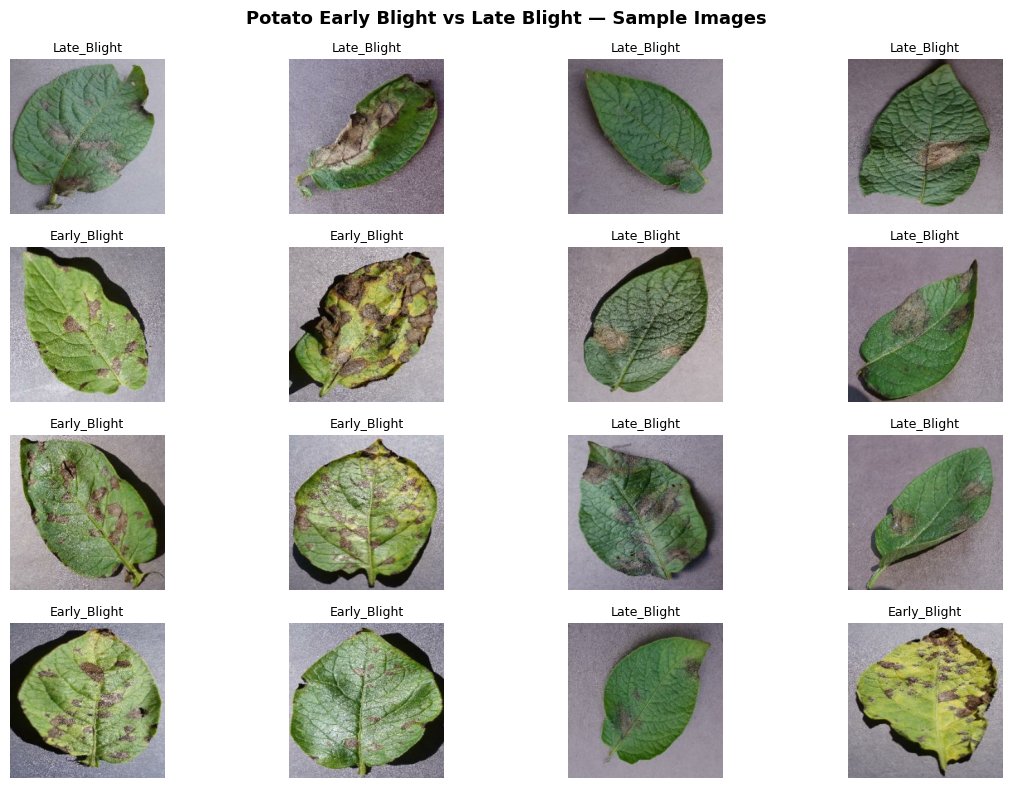

In [14]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(class_names[label_idx], fontsize=9)
    plt.axis('off')

plt.suptitle('Potato Early Blight vs Late Blight — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


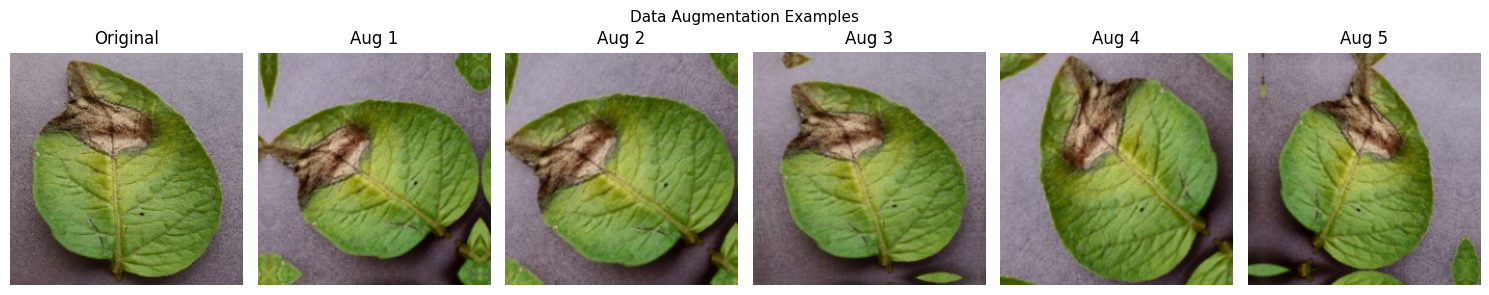

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
], name='data_augmentation')

for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 6):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()

In [17]:
def make_callbacks(name, model_dir=MODEL_DIR):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(model_dir, f'{name}_best.keras'),
            monitor='val_accuracy', save_best_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=3, min_lr=1e-7, verbose=1,
        ),
    ]


def plot_learning_curves(history, title='Learning Curves'):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc,     label='Train Accuracy',      linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss,     label='Train Loss',      linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(RESULTS_DIR + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()


def evaluate_model(model, dataset, class_names, title='Model'):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f'\n{title}')
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='d',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 11, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(' ', '_')
    plt.savefig(RESULTS_DIR + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)


print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


In [18]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

def build_transfer_model(input_shape, augmentation):
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False,
    )
    preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input

    base_model.trainable = False
    print(f'Base model      : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')

    inputs  = tf.keras.Input(shape=input_shape)
    x       = augmentation(inputs)
    x       = preprocess_fn(x)
    x       = base_model(x, training=False)
    x       = tf.keras.layers.GlobalAveragePooling2D()(x)
    x       = tf.keras.layers.Dense(128, activation='relu')(x)
    x       = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='mobilenetv2_potato'), base_model


tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model      : mobilenetv2_1.00_224
Trainable layers: 0 / 154


Model: "mobilenetv2_potato"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
# Phase 1 — Feature Extraction (base frozen)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('mobilenetv2_potato_feature_extraction'),
    verbose=1,
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6973 - loss: 0.5552
Epoch 1: val_accuracy improved from None to 0.96000, saving model to /content/drive/MyDrive/ME13/model/mobilenetv2_potato_feature_extraction_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME13/model/mobilenetv2_potato_feature_extraction_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 151ms/step - accuracy: 0.8050 - loss: 0.4183 - val_accuracy: 0.9600 - val_loss: 0.2358 - learning_rate: 1.0000e-04
Epoch 2/20
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9336 - loss: 0.2062
Epoch 2: val_accuracy improved from 0.96000 to 0.96667, saving model to /content/drive/MyDrive/ME13/model/mobilenetv2_potato_feature_extraction_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ME13/model/mobilenetv2_potato_feature_extraction_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.9486 - loss: 0.1782 - val_accuracy: 0.9667 - val_loss: 0.1547 - learning_rate: 1.0000e-

MobileNetV2 TL -> val_loss    : 0.0480
MobileNetV2 TL -> val_accuracy: 0.9833


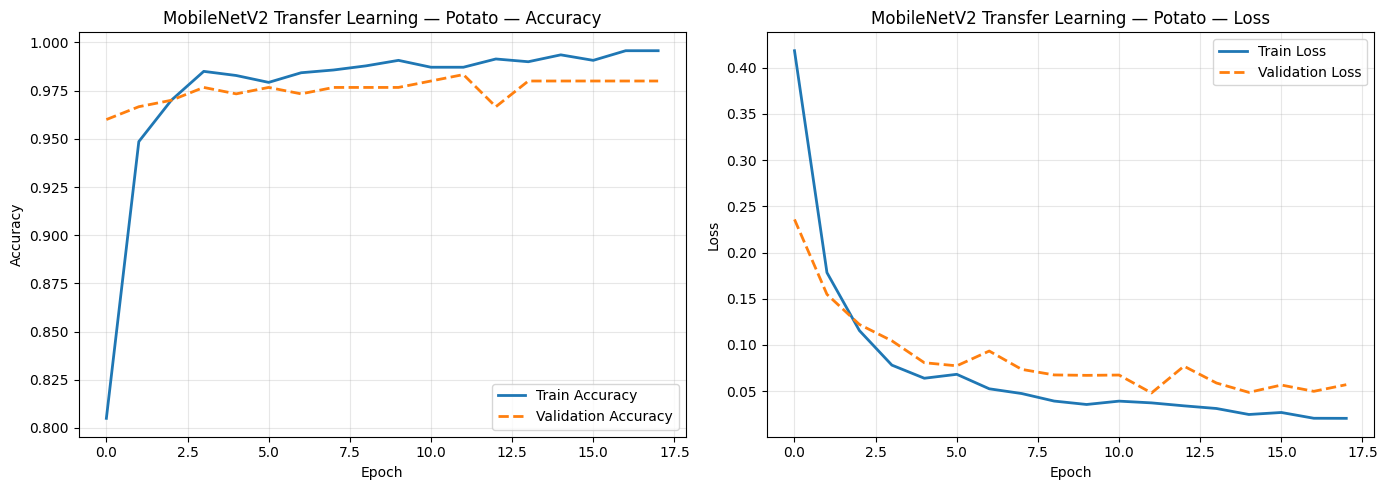

In [20]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV2 TL -> val_loss    : {tl_val_loss:.4f}')
print(f'MobileNetV2 TL -> val_accuracy: {tl_val_acc:.4f}')

plot_learning_curves(tl_history, 'MobileNetV2 Transfer Learning — Potato')


MobileNetV2 Transfer — Potato
Accuracy  : 0.9900
Precision : 0.9868
Recall    : 0.9933
F1-Score  : 0.9900

Classification Report:
              precision    recall  f1-score   support

Early_Blight     0.9933    0.9867    0.9900       150
 Late_Blight     0.9868    0.9933    0.9900       150

    accuracy                         0.9900       300
   macro avg     0.9900    0.9900    0.9900       300
weighted avg     0.9900    0.9900    0.9900       300



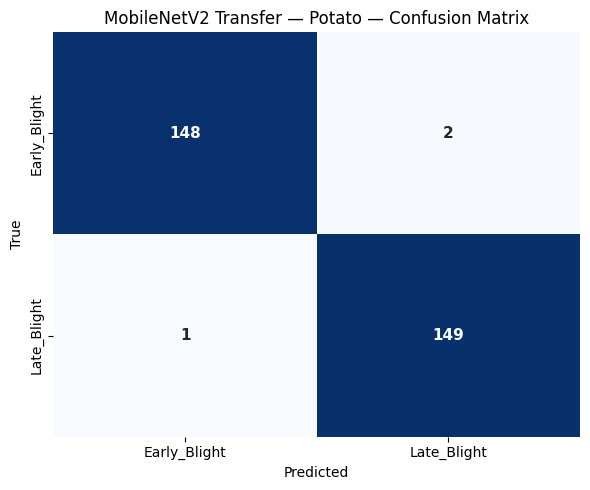

In [21]:
tl_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Transfer — Potato'
)

In [22]:
# Phase 2 — Fine-Tuning (unfreeze top 30 layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

Trainable base layers after unfreezing: 30 / 154


In [23]:
FINETUNE_LR = LR / 10   # 1e-5

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

In [24]:
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=make_callbacks('mobilenetv2_potato_finetuned'),
    verbose=1,
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9482 - loss: 0.1255
Epoch 1: val_accuracy improved from None to 0.98667, saving model to /content/drive/MyDrive/ME13/model/mobilenetv2_potato_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ME13/model/mobilenetv2_potato_finetuned_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step - accuracy: 0.9621 - loss: 0.1067 - val_accuracy: 0.9867 - val_loss: 0.0381 - learning_rate: 1.0000e-05
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9795 - loss: 0.0640
Epoch 2: val_accuracy did not improve from 0.98667
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.9836 - loss: 0.0615 - val_accuracy: 0.9867 - val_loss: 0.0338 - learning_rate: 1.0000e-05
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9805 - loss: 0.0561
Epoch 3: val_accuracy improved from 0.98667 to 0.99000, saving model to /content/drive/MyDrive/ME13/model/mobilenetv2_potato_finetuned_best.keras

Epoch

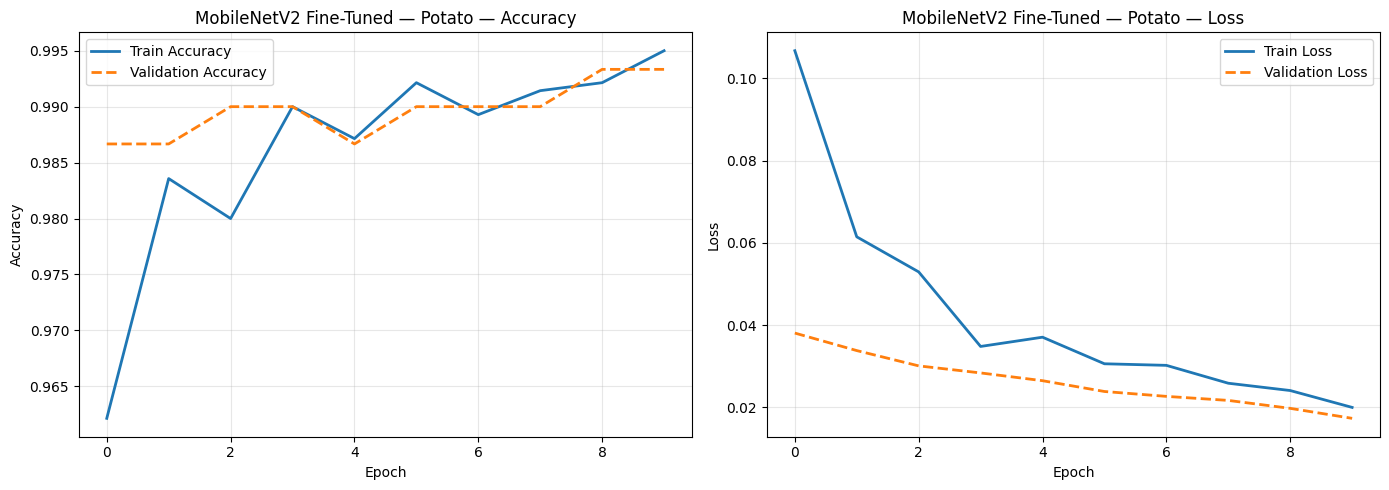


MobileNetV2 Fine-Tuned — Potato
Accuracy  : 0.9933
Precision : 0.9868
Recall    : 1.0000
F1-Score  : 0.9934

Classification Report:
              precision    recall  f1-score   support

Early_Blight     1.0000    0.9867    0.9933       150
 Late_Blight     0.9868    1.0000    0.9934       150

    accuracy                         0.9933       300
   macro avg     0.9934    0.9933    0.9933       300
weighted avg     0.9934    0.9933    0.9933       300



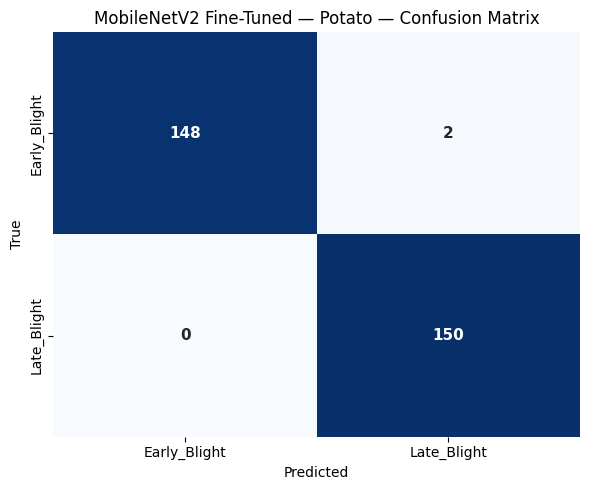


--- Summary ---
Feature-extraction test accuracy : 0.9900
Fine-tuned         test accuracy : 0.9933


In [25]:
plot_learning_curves(ft_history, 'MobileNetV2 Fine-Tuned — Potato')

ft_test_acc = evaluate_model(
    tl_model, test_dataset, class_names,
    'MobileNetV2 Fine-Tuned — Potato'
)

print('\n--- Summary ---')
print(f'Feature-extraction test accuracy : {tl_test_acc:.4f}')
print(f'Fine-tuned         test accuracy : {ft_test_acc:.4f}')

In [26]:
def predict_image(img_path, model, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """Load an image file and classify it with the trained model."""
    img       = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    prob       = model.predict(img_array, verbose=0)[0][0]
    label      = class_names[int(prob >= 0.5)]
    confidence = prob if prob >= 0.5 else 1 - prob
    print(f'Prediction : {label}')
    print(f'Confidence : {confidence:.4f}')


print('predict_image() utility defined.')
print('Usage: predict_image("/path/to/potato_leaf.jpg", tl_model, class_names)')

predict_image() utility defined.
Usage: predict_image("/path/to/potato_leaf.jpg", tl_model, class_names)


In [27]:
FINAL_MODEL_PATH = '/content/drive/MyDrive/ME13/model/potato_blight_model.keras'
tl_model.save(FINAL_MODEL_PATH)

print('Model saved:')
print(f'  {FINAL_MODEL_PATH}')
print(f'  Final test accuracy: {ft_test_acc:.4f}')

Model saved:
  /content/drive/MyDrive/ME13/model/potato_blight_model.keras
  Final test accuracy: 0.9933


In [28]:
# ── Generate class_stats.npz for OOD Layer 2 ─────────────────────────────────────────────
# Run this cell ONCE after training.
# We reload val images directly from disk (no augmentation pipeline) so the
# per-class feature statistics are clean and stable — matching what app.py
# sees at inference time.

import numpy as np
import keras

CLASS_STATS_PATH = FINAL_MODEL_PATH.replace(FINAL_MODEL_PATH.split('/')[-1], 'class_stats.npz')

# Load the saved model
saved_model = keras.models.load_model(FINAL_MODEL_PATH)
print('Model loaded from:', FINAL_MODEL_PATH)

# Build feature extractor: model.input → GlobalAveragePooling2D
gap_layer = next(
    l for l in reversed(saved_model.layers)
    if isinstance(l, keras.layers.GlobalAveragePooling2D)
)
feature_extractor = keras.Model(
    inputs=saved_model.input,
    outputs=gap_layer.output,
    name='feature_extractor',
)
print(f'Feature extractor output shape: {feature_extractor.output_shape}')

# Reload val set FRESH from disk (no cache, no augmentation)
# This ensures features match exactly what app.py computes at inference time.
val_dataset_clean = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=SEED,
    shuffle=False,
)

# Collect features and labels
all_features, all_labels = [], []
for imgs, lbls in val_dataset_clean:
    feats = feature_extractor(imgs, training=False).numpy()
    all_features.append(feats)
    all_labels.append(lbls.numpy().flatten())

all_features = np.concatenate(all_features, axis=0)  # (N, 1280)
all_labels   = np.concatenate(all_labels,   axis=0)  # (N,)
print(f'Collected {len(all_features)} val samples, feature dim={all_features.shape[1]}')

# Compute per-class mean and std
class_means, class_stds = [], []
for idx, name in enumerate(class_names):
    mask        = all_labels == idx
    class_feats = all_features[mask]
    class_means.append(class_feats.mean(axis=0))
    class_stds.append(class_feats.std(axis=0) + 1e-8)  # avoid div-by-zero
    print(f'  {name}: {mask.sum()} samples')

class_means = np.array(class_means)  # (n_classes, 1280)
class_stds  = np.array(class_stds)   # (n_classes, 1280)

# Save to Drive
np.savez(CLASS_STATS_PATH, means=class_means, stds=class_stds, class_names=class_names)
print(f'\nclass_stats.npz saved to: {CLASS_STATS_PATH}')
print('OOD Layer 2 is now enabled in the Streamlit app.')


Model loaded from: /content/drive/MyDrive/ME13/model/potato_blight_model.keras
Feature extractor output shape: (None, 1280)
Collected 300 val samples, feature dim=1280
  Early_Blight: 150 samples
  Late_Blight: 150 samples

class_stats.npz saved to: /content/drive/MyDrive/ME13/model/class_stats.npz
OOD Layer 2 is now enabled in the Streamlit app.
